# Bidirectional LSTM Sequence Return Forecaster

Long Short-Term Memory (LSTM) networks capture sequential relationships. Bidirectional LSTMs process inputs in both forward and backward directions, capturing surrounding sequence contexts. This notebook implements a Bidirectional LSTM in PyTorch to predict financial returns based on past price history sequences.



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate synthetic sinusoidal return series with phase noise (500 timestamps)
np.random.seed(81)
n_days = 500
t = np.linspace(0, 30*np.pi, n_days)
noise = np.random.normal(0, 0.15, n_days)
returns = 0.8 * np.sin(t / 2) + 0.3 * np.cos(t / 5) + noise

# Rescale returns between -1 and 1
returns = (returns - returns.mean()) / returns.std()
returns = returns.astype(np.float32)

# Prepare sequence inputs: past 10 days of returns to forecast the next day return
seq_len = 10
X_seq, y_target = [], []
for i in range(len(returns) - seq_len):
    X_seq.append(returns[i : i + seq_len])
    y_target.append(returns[i + seq_len])

X_seq = np.array(X_seq, dtype=np.float32).reshape(-1, seq_len, 1)
y_target = np.array(y_target, dtype=np.float32).reshape(-1, 1)

print(f"Data shapes: X_seq = {X_seq.shape}, y_target = {y_target.shape}")



Data shapes: X_seq = (490, 10, 1), y_target = (490, 1)


## Bidirectional LSTM PyTorch Neural Network

We define a PyTorch neural network:
1. **BiLSTM Layer**: Takes inputs of size [batch_size, sequence_length, feature_dimension] and returns bidirectional hidden dimensions.
2. **Linear Regression Head**: Combines forward and backward hidden states to output a single prediction.



In [2]:
class BiLSTMForecaster(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=16, output_dim=1):
        super(BiLSTMForecaster, self).__init__()
        self.hidden_dim = hidden_dim
        # Set batch_first=True to specify input layout
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        # Bidirectional outputs 2 * hidden_dim
        self.fc = nn.Linear(2 * hidden_dim, output_dim)
        
    def forward(self, x):
        # lstm output shape: [batch_size, seq_len, 2 * hidden_dim]
        lstm_out, _ = self.lstm(x)
        # Use final sequence step's hidden state for forecasting
        final_hidden = lstm_out[:, -1, :]
        out = self.fc(final_hidden)
        return out

model = BiLSTMForecaster(input_dim=1, hidden_dim=16)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)



## Forecaster Network Training

We split the data into 85% train and 15% test splits. We train the network for 40 epochs.



In [3]:
# Train-Test Partition
split_idx = int(len(X_seq) * 0.85)

X_train, X_test = torch.FloatTensor(X_seq[:split_idx]), torch.FloatTensor(X_seq[split_idx:])
y_train, y_test = torch.FloatTensor(y_target[:split_idx]), torch.FloatTensor(y_target[split_idx:])

# Train loop
epochs = 40
losses = []

for epoch in range(1, epochs + 1):
    model.train()
    predictions = model(X_train)
    loss = criterion(predictions, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    if epoch % 10 == 0:
        print(f"Epoch {epoch:2d}/{epochs} | Training Mean Squared Error Loss: {loss.item():.5f}")



Epoch 10/40 | Training Mean Squared Error Loss: 0.24985
Epoch 20/40 | Training Mean Squared Error Loss: 0.13055
Epoch 30/40 | Training Mean Squared Error Loss: 0.10345
Epoch 40/40 | Training Mean Squared Error Loss: 0.10108


## Forecaster Evaluation & Output Plots

We switch the model to evaluation mode, generate forecasts on the test segment, and compare predictions with actual target variables using Matplotlib.



Test Partition evaluation MSE: 0.07008


<cell>:19: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



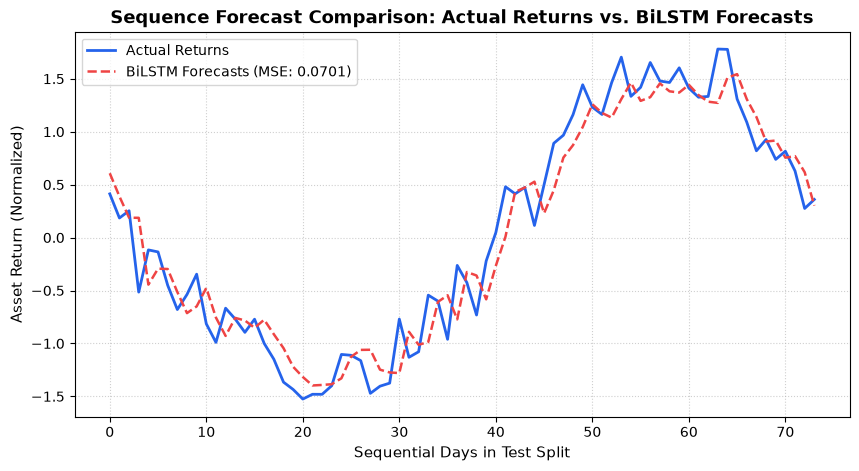

In [4]:
model.eval()
with torch.no_grad():
    test_preds = model(X_test).numpy().flatten()
    actual_test_targets = y_test.numpy().flatten()

test_mse = np.mean((test_preds - actual_test_targets) ** 2)
print(f"Test Partition evaluation MSE: {test_mse:.5f}")

# Plotting the forecast comparisons
plt.figure(figsize=(10, 5))
plt.plot(actual_test_targets, label='Actual Returns', color='#2563EB', linewidth=2)
plt.plot(test_preds, label=f'BiLSTM Forecasts (MSE: {test_mse:.4f})', color='#EF4444', linestyle='--', linewidth=1.8)

plt.title('Sequence Forecast Comparison: Actual Returns vs. BiLSTM Forecasts', fontsize=13, fontweight='bold')
plt.xlabel('Sequential Days in Test Split', fontsize=11)
plt.ylabel('Asset Return (Normalized)', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
